<img style="float: left; margin: 30px 15px 15px 15px;" src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="500" height="250" /> 
    
    
# <font color='navy'> Project: Greeks Case

<font color='black'>

- Luis Fernando Márquez Bañuelos
- Luis Eduardo Jiménez del Muro
- Fernando López Coronado
- Diego Lozoya Morales

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import scipy.stats as st
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(10)

In [2]:
class BlackScholes:
    def __init__(self, St = None, K: float = None, T: float = None, t: float = None, r: float = None, sigma: float = None):
        """
        Initialize Black-Scholes model parameters.

        Parameters:
            St (float): Spot price
            K (float): Strike price
            T (float): Time to maturity (years)
            t (float): Current time
            r (float): Risk-free interest rate
            sigma (float): Volatility of the underlying asset
        """
        if None in (St, K, T, t, r, sigma):
            self.St = 100
            self.K = 100
            self.T = 1
            self.t = 0
            self.r = 0.05
            self.sigma = 0.2
        else:
            self.St = St
            self.K = K
            self.T = T
            self.t = t
            self.r = r
            self.sigma = sigma

    # Black-Scholes formula components
    def d1(self):
        """Compute d1 in the Black-Scholes formula."""
        return (np.log(self.St / self.K) + (self.r + 0.5 * self.sigma ** 2) * (self.T - self.t)) / (self.sigma * np.sqrt(self.T - self.t))

    def d2(self):
        """Compute d2 in the Black-Scholes formula."""
        return (np.log(self.St / self.K) + (self.r - 0.5 * self.sigma ** 2) * (self.T - self.t)) / (self.sigma * np.sqrt(self.T - self.t))

    # Cumulative distribution function for a standard normal variable
    @staticmethod
    def N(x):
        """Cumulative distribution function for a standard normal variable."""
        return st.norm.cdf(x)
    
    # Option pricing methods
    def binary_cash_or_nothing_put(self):
        """Price of a Binary Cash-or-Nothing Put option."""
        return self.K * np.exp(-self.r * (self.T - self.t)) * self.N(-self.d2())

    def binary_cash_or_nothing_call(self):
        """Price of a Binary Cash-or-Nothing Call option."""
        return self.K * np.exp(-self.r * (self.T - self.t)) * self.N(self.d2())
    
    def binary_asset_or_nothing_put(self):
        """Price of a Binary Asset-or-Nothing Put option."""
        return self.St * self.N(-self.d1())

    def binary_asset_or_nothing_call(self):
        """Price of a Binary Asset-or-Nothing Call option."""
        return self.St * self.N(self.d1())
    
    # Financial options pricing methods (European options)
    def financial_call(self):
        """Price of a European Call option."""
        return self.St * self.N(self.d1()) - self.K * np.exp(-self.r * (self.T - self.t)) * self.N(self.d2())
    
    def financial_put(self):
        """Price of a European Put option."""
        return self.K * np.exp(-self.r * (self.T - self.t)) * self.N(-self.d2()) - self.St * self.N(-self.d1())
    
    # Greeks options pricing methods
    def delta_call(self):
        """Delta of a European Call option."""
        return self.N(self.d1())
    
    def delta_put(self):
        """Delta of a European Put option."""
        return self.N(self.d1()) - 1
    
    def gamma(self):
        """Gamma of the option."""
        return st.norm.pdf(self.d1()) / (self.St * self.sigma * np.sqrt(self.T - self.t))
    
    def vega(self):
        """Vega of the option."""
        return self.St * st.norm.pdf(self.d1()) * np.sqrt(self.T - self.t)
    
    def theta_call(self):
        """Theta of a European Call option."""
        return (-self.St * st.norm.pdf(self.d1()) * self.sigma / (2 * np.sqrt(self.T - self.t)) - self.r * self.K * np.exp(-self.r * (self.T - self.t)) * self.N(self.d2()))
    
    def theta_put(self):
        """Theta of a European Put option."""
        return (-self.St * st.norm.pdf(self.d1()) * self.sigma / (2 * np.sqrt(self.T - self.t)) + self.r * self.K * np.exp(-self.r * (self.T - self.t)) * self.N(-self.d2()))
    
    def rho_call(self):
        """Rho of a European Call option."""
        return self.K * (self.T - self.t) * np.exp(-self.r * (self.T - self.t)) * self.N(self.d2())
    
    def rho_put(self):
        """Rho of a European Put option."""
        return -self.K * (self.T - self.t) * np.exp(-self.r * (self.T - self.t)) * self.N(-self.d2())

    @staticmethod
    def calculate_greeks_df(df, option_type='call'):
        """
        Calculate the 5 Greeks for each row in a DataFrame.
        
        Parameters:
            df (pd.DataFrame): DataFrame with columns 'St', 'K', 'T', 't', 'r', 'sigma'
            option_type (str): Either 'call' or 'put'
        
        Returns:
            pd.DataFrame: Original DataFrame with added columns for Delta, Gamma, Vega, Theta, and Rho
        """
        if option_type.lower() not in ['call', 'put']:
            raise ValueError("option_type must be either 'call' or 'put'")
        
        # Create a copy to avoid modifying the original
        result_df = df.copy()
        
        # Initialize lists to store Greeks
        deltas = []
        gammas = []
        vegas = []
        thetas = []
        rhos = []
        
        # Calculate Greeks for each row
        for idx, row in df.iterrows():
            bs = BlackScholes(
                St=row['St'],
                K=row['K'],
                T=row['T'],
                t=row['t'],
                r=row['r'],
                sigma=row['sigma']
            )
            
            if option_type.lower() == 'call':
                deltas.append(bs.delta_call())
                thetas.append(bs.theta_call())
                rhos.append(bs.rho_call())
            else:  # put
                deltas.append(bs.delta_put())
                thetas.append(bs.theta_put())
                rhos.append(bs.rho_put())
            
            # Gamma and Vega are the same for both calls and puts
            gammas.append(bs.gamma())
            vegas.append(bs.vega())
        
        # Add Greeks as new columns
        result_df['Delta'] = deltas
        result_df['Gamma'] = gammas
        result_df['Vega'] = vegas
        result_df['Theta'] = thetas
        result_df['Rho'] = rhos
        
        return result_df

## <font color='cornflowerblue'> Data

In [3]:
data = pd.read_excel('hedge.xlsx', sheet_name='Options 2')
data

,K,Last Price,St,Date,Maturity,T,sigma,r,t2,Delta,Gamma,Vega,Theta,Rho
0,200,33.90,229.72,2025-09-02,2025-11-21,0.219178,0.310887,0.037488,0,0.860177,6.651295e-03,2.391683e+01,-23.098943,35.879409
1,210,24.85,229.72,2025-09-02,2025-11-21,0.219178,0.268119,0.037488,0,0.800457,9.695650e-03,3.006761e+01,-24.352570,34.856081
2,215,21.60,229.72,2025-09-02,2025-11-21,0.219178,0.279207,0.037488,0,0.737234,1.086105e-02,3.507455e+01,-27.879579,32.385163
3,220,17.95,229.72,2025-09-02,2025-11-21,0.219178,0.269552,0.037488,0,0.681109,1.231796e-02,3.840391e+01,-28.807833,30.359320
4,225,14.75,229.72,2025-09-02,2025-11-21,0.219178,0.264159,0.037488,0,0.616441,1.344013e-02,4.106414e+01,-29.501485,27.804686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,235,37.05,271.40,2025-11-20,2025-11-21,0.002740,0.272038,0.037488,0,1.000000,5.496127e-24,3.017260e-22,-8.808880,0.643769
146,240,32.40,271.40,2025-11-20,2025-11-21,0.002740,1.752939,0.037488,0,0.917288,6.122139e-03,2.165692e+00,-700.947745,0.593293
147,250,23.10,271.40,2025-11-20,2025-11-21,0.002740,1.537583,0.037488,0,0.855892,1.039153e-02,3.224372e+00,-912.629952,0.573121
148,260,14.75,271.40,2025-11-20,2025-11-21,0.002740,1.393856,0.037488,0,0.734364,1.656214e-02,4.658662e+00,-1191.982944,0.505634


## <font color='cornflowerblue'> Scenario 1: No Hedge

In [4]:
# Extract relevant parameters
last_price = data['St'].iloc[-1]
n_strikes = len(data['K'].unique())
r = data['r'].iloc[0]
T = data['T'].iloc[0]

# Extract premiums, strikes, and dates
premiums = data['Last Price'].iloc[0:n_strikes].values
strikes = data['K'].unique()
dates = sorted(data['Date'].unique())

In [5]:
# PnL at maturity for all options
pnl = -np.maximum(last_price - strikes, 0)

# What options (strikes) are exercised?
opt_ex = last_price - strikes > 0

In [6]:
# Premiums value at maturity
total_premiums = np.sum(premiums) * np.exp(r * T)

# Cost of buying the stocks at maturity
buy = -np.sum(opt_ex) * last_price

# Money received from selling the stocks at maturity at strike prices
sell = np.dot(opt_ex, strikes)

# Total PnL of the strategy
total = total_premiums + buy + sell

print(f"Total PnL of Scenario 1 at maturity: {total:,.2f}")

Total PnL of Scenario 1 at maturity: -257.26


## <font color='cornflowerblue'> Scenario 2: Delta Hedge

In [7]:
data_hedge = pd.read_excel('options.xlsx', sheet_name='Project Data 2')

# Drop unnecessary columns
data_hedge.drop(columns=['Contract Name','Last Trade Date (EDT)','Bid','Ask','Change','% Change','Volume','Open Interest','Implied Volatility','Type'], inplace=True)

# Merge risk-free rate data
data_hedge['r'] = 0.0382
data_hedge['t'] = 0

# Rename columns for consistency
data_hedge = data_hedge.rename(columns={'Strike': 'K', 'S0': 'St', 'Implied Vol': 'sigma', 'Rf': 'r'})

# Correct r to continuous compounding
data_hedge['r'] = np.log(1 + data_hedge['r'])

# Calculating proper implied volatilities with the adjusted risk-free rate
all_S0 = data_hedge['St'].values
K = data_hedge['K'].values
T = data_hedge['T'].values
t = data_hedge['t'].values
r = data_hedge['r'].values
sigma = data_hedge['sigma'].values
CallMKT = data_hedge['Last Price'].values

results = []
for i in range(len(data_hedge)):
    bounds = [[None, None]]
    apply_constraints1 = lambda x: BlackScholes(all_S0[i], K[i], T[i], t[i], r[i], x[0]).financial_call() - CallMKT[i]
    my_constraints = {'type': 'eq', 'fun': apply_constraints1}
    result = minimize(lambda x: 0.0,
                x0=np.array([sigma[i]]),
                bounds=bounds,
                constraints=my_constraints,
                method='SLSQP')
    implied_volatility = result.x[0]
    results.append(implied_volatility)

data_hedge['sigma'] = results
data_hedge

,K,Last Price,St,Date,Maturity,T,sigma,r,t
0,200,33.90,229.72,2025-09-02,2025-11-21,0.219178,0.310887,0.037488,0
1,210,24.85,229.72,2025-09-02,2025-11-21,0.219178,0.268119,0.037488,0
2,215,21.60,229.72,2025-09-02,2025-11-21,0.219178,0.279207,0.037488,0
3,220,17.95,229.72,2025-09-02,2025-11-21,0.219178,0.269552,0.037488,0
4,225,14.75,229.72,2025-09-02,2025-11-21,0.219178,0.264159,0.037488,0
...,...,...,...,...,...,...,...,...,...
145,235,37.05,271.40,2025-11-20,2025-11-21,0.002740,0.272038,0.037488,0
146,240,32.40,271.40,2025-11-20,2025-11-21,0.002740,1.752939,0.037488,0
147,250,23.10,271.40,2025-11-20,2025-11-21,0.002740,1.537583,0.037488,0
148,260,14.75,271.40,2025-11-20,2025-11-21,0.002740,1.393856,0.037488,0


In [8]:
# Extract premiums, strikes, and dates
premiums = data_hedge['Last Price'].iloc[0:n_strikes].values
strikes = data_hedge['K'].unique()
dates = sorted(data_hedge['Date'].unique())

# Extract relevant parameters
r = data_hedge['r'].iloc[0]
T = data_hedge['T'].iloc[0]

In [9]:
# Initialize PnL and previous delta for dynamic delta hedge
pnl = 0
previous_delta = 0

for i, dates in enumerate(dates):
    # Get data for each date
    date_data = data_hedge[data_hedge['Date'] == dates]
    date_data = date_data[['St','K','T','t','r','sigma']]

    # Compute Greeks
    bs_df = BlackScholes().calculate_greeks_df(date_data, option_type='call')

    # Calculate porfolio delta
    current_delta = bs_df['Delta'].sum()
    # Compute delta difference
    delta_diff = current_delta - previous_delta
    # How much to buy/sell
    delta_S = delta_diff * date_data['St'].iloc[0]
    commission = (0.5 / 100) * np.abs(delta_S)
    # Cumulative PnL of the strategy
    pnl += delta_S + commission
    # Update previous delta
    previous_delta = current_delta

In [10]:
# Retrieve the last price of the underlying asset
last_price = data_hedge['St'].iloc[-1]

# PnL at maturity for all options
pnl_options = -np.maximum(last_price - strikes, 0)

# What options (strikes) are exercised?
opt_ex = last_price - strikes > 0

# Premiums value at maturity
total_premiums = np.sum(premiums) * np.exp(r * T)

# Money received from selling the stocks at maturity at strike prices
sell = np.dot(opt_ex, strikes)

# Total PnL of the strategy
total = total_premiums + sell - pnl

print(f"Total PnL of Scenario 2 at maturity: {total:,.2f}")

Total PnL of Scenario 2 at maturity: 207.70


## <font color='cornflowerblue'> Scenario 3: Delta-Gamma Hedge

In [11]:
# Extract premiums, strikes, and dates
premiums = data_hedge['Last Price'].iloc[0:n_strikes].values
strikes = data_hedge['K'].unique()
dates = sorted(data_hedge['Date'].unique())

# Extract relevant parameters
r = data_hedge['r'].iloc[0]
T = data_hedge['T'].iloc[0]
lower_threshold = 0.08217612582697384
upper_threshold = 0.1022501127623168
adjust_factor = 0.1

In [12]:
# Initialize PnL and previous delta for dynamic delta-gamma hedge
pnl = 0
previous_delta = 0

for i, dates in enumerate(dates):
    # Get data for each date
    date_data = data_hedge[data_hedge['Date'] == dates]
    date_data = date_data[['St','K','T','t','r','sigma']]

    # Compute Greeks
    bs_df = BlackScholes().calculate_greeks_df(date_data, option_type='call')

    # Calculate porfolio delta
    current_delta = bs_df['Delta'].sum()
    # Calculate gamma of the portfolio
    current_gamma = bs_df['Gamma'].sum()

    # Adjust delta based on gamma
    if current_gamma > upper_threshold:
        current_delta *= (1 + adjust_factor)
    elif current_gamma < lower_threshold:
        current_delta *= (1 - adjust_factor)
    else:
        current_delta = current_delta

    # Compute delta difference
    delta_diff = current_delta - previous_delta
    # How much to buy/sell
    delta_S = delta_diff * date_data['St'].iloc[0]
    commission = (0.5 / 100) * np.abs(delta_S)
    # Cumulative PnL of the strategy
    pnl += delta_S + commission
    # Update previous delta
    previous_delta = current_delta

In [13]:
# Retrieve the last price of the underlying asset
last_price = data_hedge['St'].iloc[-1]

# PnL at maturity for all options
pnl_options = -np.maximum(last_price - strikes, 0)

# What options (strikes) are exercised?
opt_ex = last_price - strikes > 0

# Premiums value at maturity
total_premiums = np.sum(premiums) * np.exp(r * T)

# Money received from selling the stocks at maturity at strike prices
sell = np.dot(opt_ex, strikes)

# Total PnL of the strategy
total = total_premiums + sell - pnl

print(f"Total PnL of Scenario 3 at maturity: {total:,.2f}")

Total PnL of Scenario 3 at maturity: 469.22


## <font color='cornflowerblue'> Simulations

### <font color='steelblue'> Scenario 1: No Hedge

In [14]:
# Get daily stock data of the asset
df = yf.download('AAPL', start='2020-01-01', end='2025-11-11', auto_adjust=True, progress=False)['Close']
# Get daily returns
rt = df.pct_change().dropna().values

# Annual return and volatility
mu = np.mean(rt) * 252
sigma = np.std(rt) * np.sqrt(252)

# Get St and T in order
df_unique = data[['Date', 'St', 'T']].drop_duplicates().sort_values('Date').reset_index(drop=True)
# Get time jumps for simulated prices
diff_t = -(df_unique['T'].diff().fillna(0))

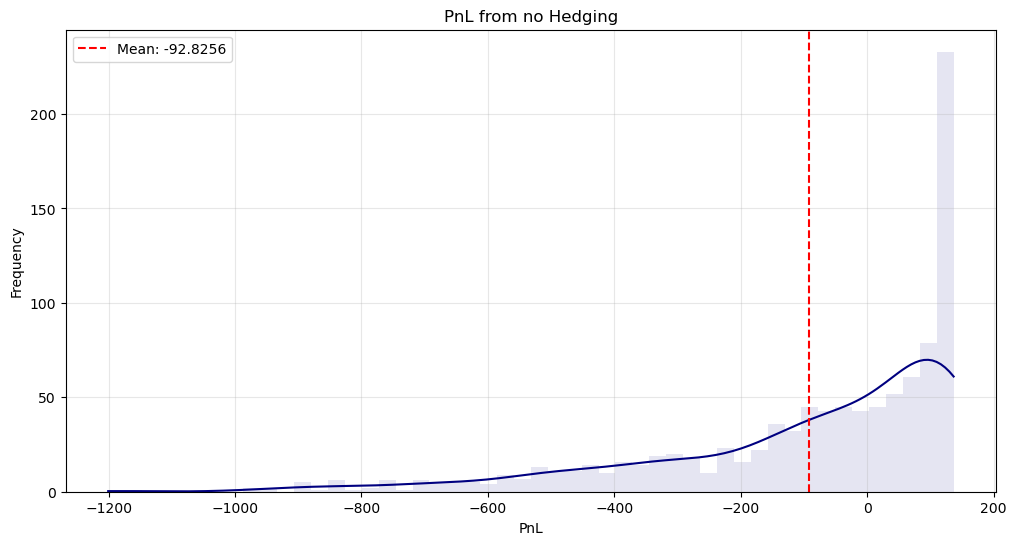

Probability of losing money without hedging: 52.30%
95% VaR without hedging: -602.49


In [15]:
pnl_distribution = []

for i in range(1000):
    # Final price simulation
    sim_prices = []
    St = data['St'].iloc[0]
    for i in range(len(diff_t)):
        St = St * np.exp(diff_t[i] * (mu - sigma**2/2) + np.sqrt(diff_t[i]) * sigma * np.random.normal(0, 1))
        sim_prices.append(St)

    # Extract relevant parameters
    last_price = sim_prices[-1]
    n_strikes = len(data['K'].unique())
    r = data['r'].iloc[0]
    T = data['T'].iloc[0]

    # Extract premiums, strikes, and dates
    premiums = data['Last Price'].iloc[0:n_strikes].values
    strikes = data['K'].unique()
    dates = sorted(data['Date'].unique())

    # PnL at maturity for all options
    pnl = -np.maximum(last_price - strikes, 0)

    # What options (strikes) are exercised?
    opt_ex = last_price - strikes > 0

    # Premiums value at maturity
    total_premiums = np.sum(premiums) * np.exp(r * T)

    # Cost of buying the stocks at maturity
    buy = -np.sum(opt_ex) * last_price

    # Money received from selling the stocks at maturity at strike prices
    sell = np.dot(opt_ex, strikes)

    # Total PnL of the strategy
    total = total_premiums + buy + sell
    pnl_distribution.append(total)

# PnL plot distribution
plt.figure(figsize=(12, 6))
sns.histplot(pnl_distribution, color='navy', alpha=0.1, kde=True, bins=50, edgecolor=None)
plt.title('PnL from no Hedging')
plt.xlabel('PnL')
plt.ylabel('Frequency')
plt.axvline(x=np.mean(pnl_distribution), color='red', linestyle='--', label=f'Mean: {np.mean(pnl_distribution):.4f}')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

prob_losing = np.mean(np.array(pnl_distribution) < 0)
var_95 = np.percentile(pnl_distribution, 5)

print(f"Probability of losing money without hedging: {prob_losing:.2%}")
print(f"95% VaR without hedging: {var_95:.2f}")

### <font color='steelblue'> Scenario 2: Delta Hedge

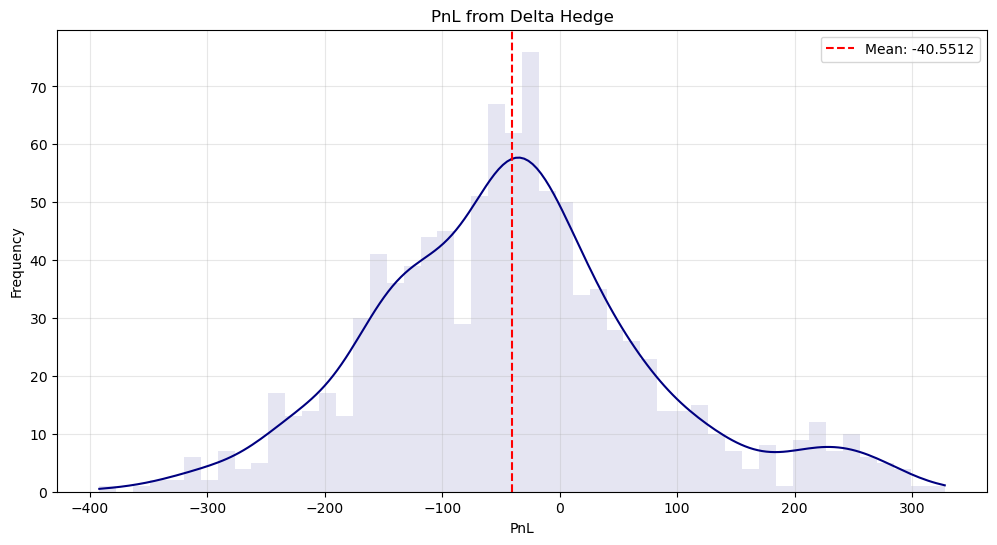

Probability of losing money with Delta hedge: 68.30%
95% VaR with Delta hedge: -226.74


In [16]:
pnl_distribution = []

# Extract premiums, strikes, and dates
premiums = data_hedge['Last Price'].iloc[0:n_strikes].values
strikes = data_hedge['K'].unique()
dates = sorted(data_hedge['Date'].unique())

# Extract relevant parameters
r = data_hedge['r'].iloc[0]
T = data_hedge['T'].iloc[0]

for sim in range(1000):
    # Reset St for each simulation
    St = data['St'].iloc[0]

    # Initialize PnL and previous delta for dynamic delta hedge
    pnl = 0
    previous_delta = 0

    for i in range(len(dates)):
        # Get data for each date
        date_data = data_hedge[data_hedge['Date'] == dates[i]]

        # Simulate price
        St = St * np.exp(diff_t[i] * (mu - sigma**2/2) + np.sqrt(diff_t[i]) * sigma * np.random.normal(0, 1))
        
        # Apply the simulated St to the dataset
        date_data = date_data.copy()
        date_data['St'] = St
        date_data = date_data[['St','K','T','t','r','sigma']]

        # Compute Greeks
        bs_df = BlackScholes().calculate_greeks_df(date_data, option_type='call')

        # Calculate porfolio delta
        current_delta = bs_df['Delta'].sum()
        # Compute delta difference
        delta_diff = current_delta - previous_delta
        # How much to buy/sell
        delta_S = delta_diff * date_data['St'].iloc[0]
        commission = (0.5 / 100) * np.abs(delta_S)
        # Cumulative PnL of the strategy
        pnl += delta_S + commission
        # Update previous delta
        previous_delta = current_delta

    # Retrieve the last price of the underlying asset
    last_price = St

    # PnL at maturity for all options
    pnl_options = -np.maximum(last_price - strikes, 0)

    # What options (strikes) are exercised?
    opt_ex = last_price - strikes > 0

    # Premiums value at maturity
    total_premiums = np.sum(premiums) * np.exp(r * T)

    # Money received from selling the stocks at maturity at strike prices
    sell = np.dot(opt_ex, strikes)

    # Total PnL of the strategy
    total = total_premiums + sell - pnl
    pnl_distribution.append(total)

# PnL plot distribution
plt.figure(figsize=(12, 6))
sns.histplot(pnl_distribution, color='navy', alpha=0.1, kde=True, bins=50, edgecolor=None)
plt.title('PnL from Delta Hedge')
plt.xlabel('PnL')
plt.ylabel('Frequency')
plt.axvline(x=np.mean(pnl_distribution), color='red', linestyle='--', label=f'Mean: {np.mean(pnl_distribution):.4f}')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

prob_losing = np.mean(np.array(pnl_distribution) < 0)
var_95 = np.percentile(pnl_distribution, 5)

print(f"Probability of losing money with Delta hedge: {prob_losing:.2%}")
print(f"95% VaR with Delta hedge: {var_95:.2f}")

### <font color='steelblue'> Scenario 3: Delta-Gamma Hedge

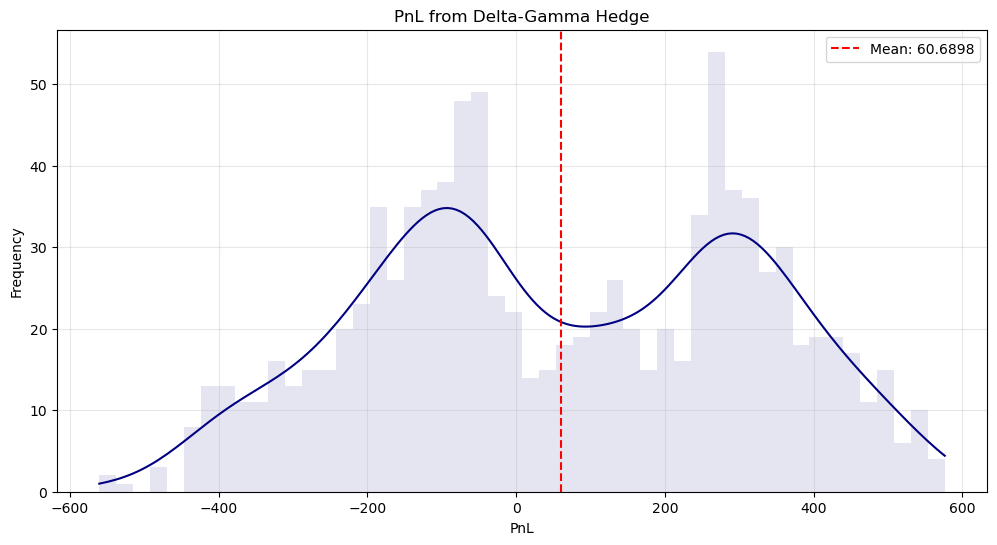

Probability of losing money with Delta-Gamma hedge: 47.40%
95% VaR with Delta-Gamma hedge: -358.19


In [17]:
pnl_distribution = []

# Extract premiums, strikes, and dates
premiums = data_hedge['Last Price'].iloc[0:n_strikes].values
strikes = data_hedge['K'].unique()
dates = sorted(data_hedge['Date'].unique())

# Extract relevant parameters
r = data_hedge['r'].iloc[0]
T = data_hedge['T'].iloc[0]
lower_threshold = 0.08217612582697384
upper_threshold = 0.1022501127623168

adjust_factor = 0.1

for sim in range(1000):
    # Reset St for each simulation
    St = data['St'].iloc[0]
    # Initialize PnL and previous delta for dynamic delta-gamma hedge
    pnl = 0
    previous_delta = 0

    for i in range(len(dates)):
        # Get data for each date
        date_data = data_hedge[data_hedge['Date'] == dates[i]]

        # Simulate price
        St = St * np.exp(diff_t[i] * (mu - sigma**2/2) + np.sqrt(diff_t[i]) * sigma * np.random.normal(0, 1))

        # Apply the simulated St to the dataset
        date_data = date_data.copy()
        date_data['St'] = St
        date_data = date_data[['St','K','T','t','r','sigma']]

        # Compute Greeks
        bs_df = BlackScholes().calculate_greeks_df(date_data, option_type='call')

        # Calculate porfolio delta
        current_delta = bs_df['Delta'].sum()
        # Calculate gamma of the portfolio
        current_gamma = bs_df['Gamma'].sum()

        # Adjust delta based on gamma
        if current_gamma > upper_threshold:
            current_delta *= (1 + adjust_factor)
        elif current_gamma < lower_threshold:
            current_delta *= (1 - adjust_factor)
        else:
            current_delta = current_delta

        # Compute delta difference
        delta_diff = current_delta - previous_delta
        # How much to buy/sell
        delta_S = delta_diff * date_data['St'].iloc[0]
        commission = (0.5 / 100) * np.abs(delta_S)
        # Cumulative PnL of the strategy
        pnl += delta_S + commission
        # Update previous delta
        previous_delta = current_delta

    # Retrieve the last price of the underlying asset
    last_price = St

    # PnL at maturity for all options
    pnl_options = -np.maximum(last_price - strikes, 0)

    # What options (strikes) are exercised?
    opt_ex = last_price - strikes > 0

    # Premiums value at maturity
    total_premiums = np.sum(premiums) * np.exp(r * T)

    # Money received from selling the stocks at maturity at strike prices
    sell = np.dot(opt_ex, strikes)

    # Total PnL of the strategy
    total = total_premiums + sell - pnl
    pnl_distribution.append(total)

# PnL plot distribution
plt.figure(figsize=(12, 6))
sns.histplot(pnl_distribution, color='navy', alpha=0.1, kde=True, bins=50, edgecolor=None)
plt.title('PnL from Delta-Gamma Hedge')
plt.xlabel('PnL')
plt.ylabel('Frequency')
plt.axvline(x=np.mean(pnl_distribution), color='red', linestyle='--', label=f'Mean: {np.mean(pnl_distribution):.4f}')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

prob_losing = np.mean(np.array(pnl_distribution) < 0)
var_95 = np.percentile(pnl_distribution, 5)

print(f"Probability of losing money with Delta-Gamma hedge: {prob_losing:.2%}")
print(f"95% VaR with Delta-Gamma hedge: {var_95:.2f}")

### <font color='steelblue'> Implied Volatility Analysis

In [18]:
data_vol = pd.read_excel('hedge.xlsx', sheet_name='Options 2')
data_vol.head(10)

,K,Last Price,St,Date,Maturity,T,sigma,r,t2,Delta,Gamma,Vega,Theta,Rho
0,200,33.90,229.72,2025-09-02,2025-11-21,0.219178,0.310887,0.037488,0,0.860177,0.006651,23.916826,-23.098943,35.879409
1,210,24.85,229.72,2025-09-02,2025-11-21,0.219178,0.268119,0.037488,0,0.800457,0.009696,30.067610,-24.352570,34.856081
2,215,21.60,229.72,2025-09-02,2025-11-21,0.219178,0.279207,0.037488,0,0.737234,0.010861,35.074547,-27.879579,32.385163
3,220,17.95,229.72,2025-09-02,2025-11-21,0.219178,0.269552,0.037488,0,0.681109,0.012318,38.403908,-28.807833,30.359320
4,225,14.75,229.72,2025-09-02,2025-11-21,0.219178,0.264159,0.037488,0,0.616441,0.013440,41.064143,-29.501485,27.804686
5,235,9.12,229.72,2025-09-02,2025-11-21,0.219178,0.248068,0.037488,0,0.473350,0.014920,42.809181,-27.960494,21.834080
6,240,6.82,229.72,2025-09-02,2025-11-21,0.219178,0.239521,0.037488,0,0.397024,0.014968,41.467553,-25.821652,18.495174
7,250,3.60,229.72,2025-09-02,2025-11-21,0.219178,0.229683,0.037488,0,0.255726,0.013019,34.585640,-20.188995,12.086632
8,260,1.79,229.72,2025-09-02,2025-11-21,0.219178,0.225943,0.037488,0,0.149171,0.009560,24.982936,-14.094583,7.118381
9,265,1.24,229.72,2025-09-02,2025-11-21,0.219178,0.225362,0.037488,0,0.110572,0.007787,20.297961,-11.341058,5.295467


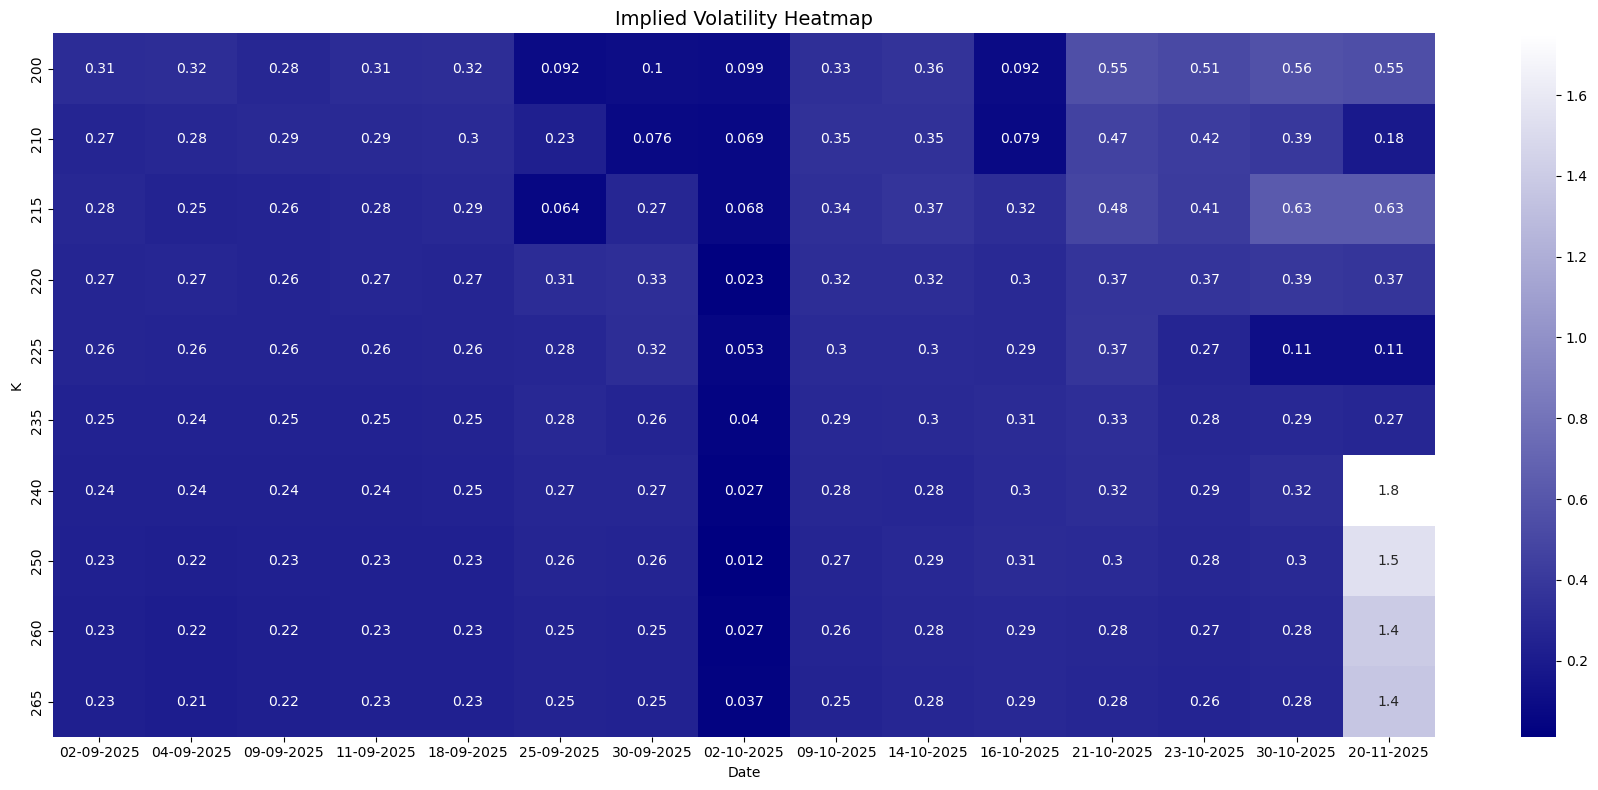

In [19]:
data_vol['Date'] = pd.to_datetime(data_vol['Date'])
data_vol['Date_fmt'] = data_vol['Date'].dt.strftime('%d-%m-%Y')

# Desired chronological order of labels
order = (
    data_vol
    .sort_values('Date')['Date_fmt']
    .unique()
)

pivot = data_vol.pivot_table(
    index='K',
    columns='Date_fmt',
    values='sigma'
)

# Reorder columns according to chronological order
pivot = pivot.reindex(columns=order)

custom_cmap = LinearSegmentedColormap.from_list(
    "navy_white",
    ["navy", "white"]
)

plt.figure(figsize=(18, 8))
sns.heatmap(pivot, cmap=custom_cmap, annot=True)
plt.title('Implied Volatility Heatmap',fontsize=14)
plt.xlabel('Date')
plt.ylabel('K')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()